In [350]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from openpyxl import load_workbook

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


In [351]:
ROOT = Path.cwd()
DATA_DIR = ROOT / 'data'
RAW_DIR = DATA_DIR / 'raw'
OUTPUT_DIR = ROOT / 'output'

CBR_INFL_EXP_PATH = RAW_DIR / 'cbr_infl_exp_26_03.xlsx'
ROSSTAT_IPC_PATH = RAW_DIR / 'rosstat_ipc_monthly_1991_2026.xlsx'
MOEX_USD_TOM_PATH = RAW_DIR / 'moex_usd_tom_2014_2026.json'
CPI_MM_SA_PATH = RAW_DIR / 'indicators_cpd.xlsx'

OUTPUT_PANEL_PATH = OUTPUT_DIR / 'cbr_determinants_panel.csv'
OUTPUT_COVERAGE_PATH = OUTPUT_DIR / 'cbr_determinants_coverage.csv'
ARTICLE_PATH = OUTPUT_DIR / 'cbr_determinants_article_sample.csv'

ARTICLE_START = pd.Timestamp('2014-01-31')
ARTICLE_END = pd.Timestamp('2024-05-31')


In [352]:
def to_month_end(value: object) -> pd.Timestamp:
    return pd.to_datetime(value).to_period('M').to_timestamp('M')


def extract_row_series(
    workbook_path: Path,
    sheet_name: str,
    date_row: int,
    value_row: int,
    start_col: int = 2,
) -> pd.Series:
    wb = load_workbook(workbook_path, read_only=True, data_only=True)
    ws = wb[sheet_name]

    first_row = min(date_row, value_row)
    row_count = abs(value_row - date_row) + 1
    rows = list(
        ws.iter_rows(
            min_row=first_row,
            max_row=first_row + row_count - 1,
            min_col=start_col,
            max_col=ws.max_column,
            values_only=True,
        )
    )
    row_dates = rows[date_row - first_row]
    row_values = rows[value_row - first_row]

    dates: list[pd.Timestamp] = []
    values: list[float | None] = []
    for date_value, series_value in zip(row_dates, row_values):
        if date_value is None:
            continue
        dates.append(to_month_end(date_value))
        values.append(None if series_value is None else float(series_value))

    series = pd.Series(values, index=pd.DatetimeIndex(dates)).sort_index()
    series.index.name = 'date'
    return series


def extract_cpi_series(workbook_path: Path) -> pd.Series:
    wb = load_workbook(workbook_path, read_only=True, data_only=True)
    ws = wb['01']
    month_rows = {
        'январь': 6,
        'февраль': 7,
        'март': 8,
        'апрель': 9,
        'май': 10,
        'июнь': 11,
        'июль': 12,
        'август': 13,
        'сентябрь': 14,
        'октябрь': 15,
        'ноябрь': 16,
        'декабрь': 17,
    }

    records: list[tuple[pd.Timestamp, float]] = []
    for col in range(2, ws.max_column + 1):
        year_value = ws.cell(4, col).value
        if not isinstance(year_value, int):
            continue
        for month_name, row in month_rows.items():
            cell_value = ws.cell(row, col).value
            if cell_value is None:
                continue
            month_number = list(month_rows).index(month_name) + 1
            date_value = pd.Timestamp(year=year_value, month=month_number, day=1).to_period('M').to_timestamp('M')
            records.append((date_value, float(cell_value)))

    series = pd.Series(dict(records)).sort_index()
    series.index.name = 'date'
    return series

def extract_cpi_expectations(workbook_path: Path) -> pd.Series:
    series = extract_row_series(
        workbook_path=workbook_path,
        sheet_name='Данные за все годы',
        date_row=2,
        value_row=71,
        start_col=2,
    )
    series.name = 'CPI_exp'
    return series


def load_moex_usd_close(workbook_path: Path) -> pd.DataFrame:
    chunk_paths = sorted(
        [
            path
            for path in workbook_path.parent.glob('moex_usd_tom_*.json')
            if path.is_file() and path.stat().st_size > 200
        ],
        key=lambda path: (
            int(re.search(r'moex_usd_tom_(\d+)', path.stem).group(1))
            if re.search(r'moex_usd_tom_(\d+)', path.stem)
            else 10**9
        ),
    )
    if not chunk_paths:
        chunk_paths = [workbook_path]

    records: list[tuple[pd.Timestamp, float]] = []
    for path in chunk_paths:
        with open(path, 'r', encoding='utf-8') as fh:
            payload = json.load(fh)

        columns = payload['candles']['columns']
        idx_begin = columns.index('begin')
        idx_close = columns.index('close')
        for row in payload['candles']['data']:
            records.append((pd.to_datetime(row[idx_begin]), float(row[idx_close])))

    frame = (
        pd.DataFrame(records, columns=['date', 'close'])
        .drop_duplicates(subset=['date'], keep='last')
        .sort_values('date')
        .reset_index(drop=True)
    )
    return frame


def build_usd_volatility(daily_close: pd.DataFrame) -> pd.Series:
    frame = daily_close.copy()
    frame['log_return'] = np.log(frame['close']).diff()
    frame = frame.dropna(subset=['log_return'])
    frame['month_end'] = frame['date'].dt.to_period('M').dt.to_timestamp('M')

    monthly_vol = (
        frame.groupby('month_end')['log_return']
        .std(ddof=0)
        .mul(100.0)
        .rename('USD_vol')
        .sort_index()
    )
    monthly_vol.index.name = 'date'
    return monthly_vol


In [ ]:
cpi_index = extract_cpi_series(ROSSTAT_IPC_PATH).loc[:ARTICLE_END]
seasonal = pd.read_csv('data/seasonal_infl.csv')
cpi = (
    seasonal.set_index("seasonal_infl")
    .loc["Все товары и услуги"]
    .rename("CPI_mmSA")
)
core = (
    seasonal.set_index("seasonal_infl")
    .loc["Базовый ИПЦ"]
    .rename("coreCPI_mmSA")
)
cpi_sa = pd.concat([cpi, core], axis=1).reset_index()
cpi_sa = cpi_sa.rename(columns={"index": "date"})
cpi_sa["date"] = pd.to_datetime(cpi_sa["date"], format="%m/%y") + pd.offsets.MonthEnd(0)
for col in ["CPI_mmSA", "coreCPI_mmSA"]:
        cpi_sa[col] = pd.to_numeric(cpi_sa[col], errors="coerce")

cpi_sa = cpi_sa.sort_values("date").reset_index(drop=True)
cpi_sa.index = cpi_sa['date']
cpi_sa = cpi_sa.loc[:ARTICLE_END]
cpi_sa["coreCPI_mmSA_t-1"] = cpi_sa["coreCPI_mmSA"].shift(1)
cpi_sa.to_csv('data/seasonal_infl_determinants.csv')
cpi_mm_sa = cpi_sa['CPI_mmSA']
coreCPI_mmSA = cpi_sa['coreCPI_mmSA']
coreCPI_mmSA_t_1 = cpi_sa['coreCPI_mmSA_t-1']

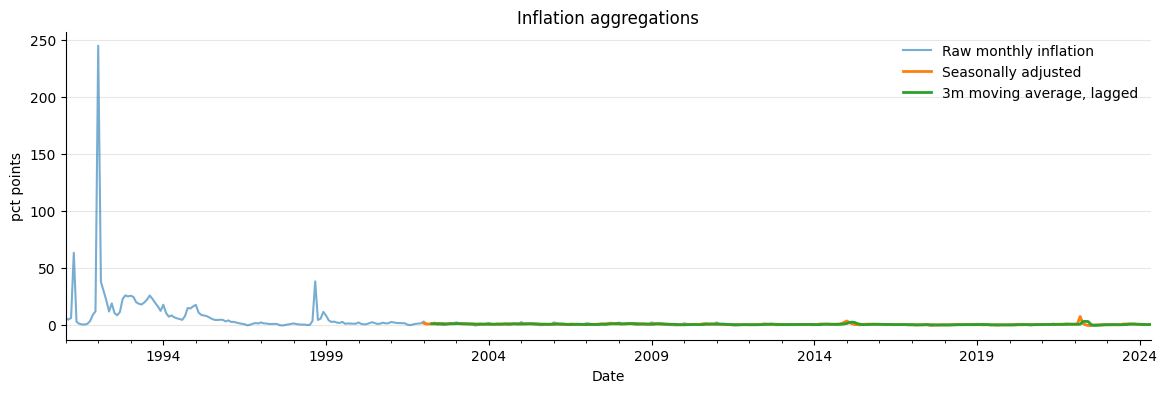

In [354]:

cpi_mm_raw = (cpi_index - 100.0).rename('CPI_mm_raw')
cpi_mm_sa_t1 = cpi_mm_sa.shift(1).rename('CPI_mmSA_t-1')
cpi_mm_sa_3mma_t1 = cpi_mm_sa.rolling(3, min_periods=3).mean().shift(1).rename('CPI_mmSA_3mMA_t-1')

fig, ax = plt.subplots(figsize=(14, 4))
cpi_mm_raw.plot(ax=ax, lw=1.5, alpha=0.6, label='Raw monthly inflation')
cpi_mm_sa.plot(ax=ax, lw=2, label='Seasonally adjusted')
cpi_mm_sa_3mma_t1.plot(ax=ax, lw=2, label='3m moving average, lagged')
ax.set_title('Inflation aggregations')
ax.set_ylabel('pct points')
ax.set_xlabel('Date')
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.3)
plt.show()


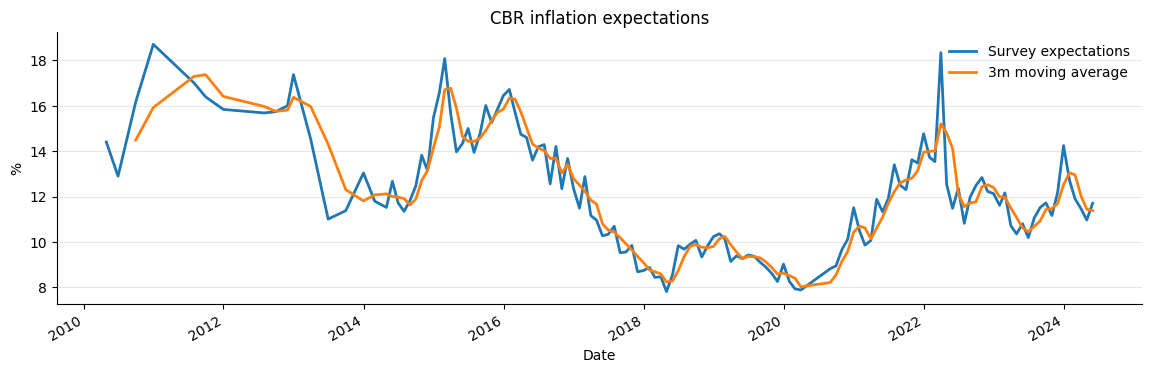

In [355]:
cpi_exp = extract_cpi_expectations(CBR_INFL_EXP_PATH).rename('CPI_exp').loc[:ARTICLE_END]
cpi_exp_3mma = cpi_exp.rolling(3, min_periods=3).mean().rename('CPI_exp_3mSA').loc[:ARTICLE_END]

fig, ax = plt.subplots(figsize=(14, 4))
cpi_exp.plot(ax=ax, lw=2, label='Survey expectations')
cpi_exp_3mma.plot(ax=ax, lw=2, label='3m moving average')
ax.set_title('CBR inflation expectations')
ax.set_ylabel('%')
ax.set_xlabel('Date')
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.3)
plt.show()


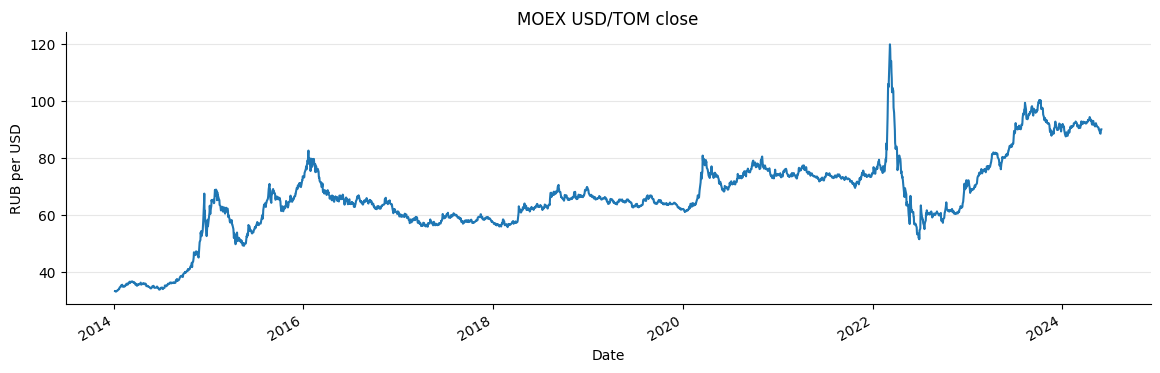

In [356]:
usd_daily = load_moex_usd_close(MOEX_USD_TOM_PATH)
usd_daily.index = usd_daily['date']
usd_daily = usd_daily.loc[:ARTICLE_END]
usd_vol = build_usd_volatility(usd_daily)
usd_vol_t1 = usd_vol.shift(1).rename('USD_vol_t-1')
fig, ax = plt.subplots(figsize=(14, 4))
usd_daily.set_index('date')['close'].plot(ax=ax, lw=1.5)
ax.set_title('MOEX USD/TOM close')
ax.set_ylabel('RUB per USD')
ax.set_xlabel('Date')
ax.grid(True, axis='y', alpha=0.3)
plt.show()


In [357]:
determinants = pd.concat(
    [
        cpi_index.rename("CPI_index"),
        cpi_mm_raw.rename("CPI_mm_raw"),
        cpi_mm_sa.rename("CPI_mmSA"),
        cpi_mm_sa_t1.rename("CPI_mmSA_t-1"),
        cpi_mm_sa_3mma_t1.rename("CPI_mmSA_3mMA_t-1"),
        cpi_exp.rename("CPI_exp"),
        cpi_exp_3mma.rename("CPI_exp_3mSA"),
        usd_vol.rename("USD_vol"),
        usd_vol_t1.rename("USD_vol_t-1"),
        cpi_mm_sa,
        coreCPI_mmSA,
        coreCPI_mmSA_t_1
    ],
    axis=1,
).sort_index()

determinants = determinants.ffill()
determinants = determinants.loc[ARTICLE_START:]
determinants.index.name = "date"
determinants = determinants.reset_index()

determinants.to_csv(DATA_DIR / "cbr_determinants.csv", index=False)

display(determinants.head(10))


,date,CPI_index,CPI_mm_raw,CPI_mmSA,CPI_mmSA_t-1,CPI_mmSA_3mMA_t-1,CPI_exp,CPI_exp_3mSA,USD_vol,USD_vol_t-1,CPI_mmSA,coreCPI_mmSA,coreCPI_mmSA_t-1
0,2014-01-31,100.5900,0.5900,0.2900,0.3200,0.4900,13.0377,11.8079,0.4915,NaN,0.2900,0.3000,0.4000
1,2014-02-28,100.7000,0.7000,0.5800,0.2900,0.3667,11.7952,12.0707,0.5841,0.4915,0.5800,0.5000,0.3000
2,2014-03-31,101.0200,1.0200,0.9700,0.5800,0.3967,11.7952,12.0707,0.7905,0.5841,0.9700,0.7500,0.5000
3,2014-04-30,100.9000,0.9000,0.9200,0.9700,0.6133,11.5221,12.1183,0.5827,0.7905,0.9200,0.8700,0.7500
4,2014-05-31,100.9000,0.9000,0.9000,0.9200,0.8233,12.6727,11.9967,0.5259,0.5827,0.9000,0.9300,0.8700
5,2014-06-30,100.6200,0.6200,0.6500,0.9000,0.9300,11.7210,11.9719,0.5417,0.5259,0.6500,0.8900,0.9300
6,2014-07-31,100.4900,0.4900,0.4600,0.6500,0.8233,11.3488,11.9142,0.6775,0.5417,0.4600,0.7500,0.8900
7,2014-08-31,100.2400,0.2400,0.6700,0.4600,0.6700,11.8304,11.6334,0.5298,0.6775,0.6700,0.6700,0.7500
8,2014-09-30,100.6500,0.6500,0.9300,0.6700,0.5933,12.4592,11.8795,0.7315,0.5298,0.9300,0.7100,0.6700
9,2014-10-31,100.8200,0.8200,0.8400,0.9300,0.6867,13.8173,12.7023,1.2051,0.7315,0.8400,0.7800,0.7100
